In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! pip install ipympl

  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.3/516.3 kB 2.8 MB/s eta 0:00:00
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
folderpath = '/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine'

In [ ]:
excel_filepath = os.path.join(folderpath, 'bad_fish_height_data.xlsx')
bad_df = pd.read_excel(excel_filepath)
bad_df.head()

,filename,height
0,20231201092318649_sardine_bad.jpeg,0.0
1,20231205093846774_sardine_bad.jpeg,0.0
2,20231205093856709_sardine_bad.jpeg,0.0
3,20231217101935383_sardine_bad.jpeg,0.0
4,20231217101956087_sardine_bad.jpeg,0.0


In [ ]:
excel_filepath = os.path.join(folderpath, 'good_fish_height_data.xlsx')
good_df = pd.read_excel(excel_filepath)
good_df.head()

,filename,height
0,20240213114729506_sardine_good.jpeg,15.5
1,20240213115920693_sardine_good.jpeg,17.2
2,20240213115928524_sardine_good.jpeg,18.0
3,20240213115938035_sardine_good.jpeg,18.1
4,20240213115949041_sardine_good.jpeg,19.1


In [ ]:
bad_df.shape, good_df.shape

((474, 2), (484, 2))

In [ ]:
def delete_duplicate_filenames_rows(df):
    # Keep max index row for duplicate filenames
    df = df.loc[df.groupby('filename').apply(lambda x: x.index.max())]
    return df.reset_index(drop=True)

def extract_date(filename):
    return f"{filename[:4]}-{filename[4:6]}-{filename[6:8]}"

def process_df(df):
    # Remove duplicates, extract date, filter by height, and reset index
    df = delete_duplicate_filenames_rows(df)
    df['date'] = df['filename'].apply(extract_date)
    df = df[df['height'] >= 1].reset_index(drop=True)
    return df

# Apply processing to both bad_df and good_df
bad_df, good_df = map(process_df, [bad_df, good_df])

# Check shapes
bad_df.shape, good_df.shape


((448, 3), (467, 3))

In [ ]:
bad_df.head()

,filename,height,date
0,20240130093208534_sardine_bad.jpeg,13.0,2024-01-30
1,20240130093304262_sardine_bad.jpeg,14.5,2024-01-30
2,20240130093323026_sardine_bad.jpeg,12.9,2024-01-30
3,20240130093336802_sardine_bad.jpeg,13.3,2024-01-30
4,20240130093404006_sardine_bad.jpeg,14.4,2024-01-30


In [ ]:
good_df.head()

,filename,height,date
0,20240213114729506_sardine_good.jpeg,15.5,2024-02-13
1,20240213115920693_sardine_good.jpeg,17.2,2024-02-13
2,20240213115928524_sardine_good.jpeg,18.0,2024-02-13
3,20240213115938035_sardine_good.jpeg,18.1,2024-02-13
4,20240213115949041_sardine_good.jpeg,19.1,2024-02-13


In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
# from google.colab import output
# output.disable_custom_widget_manager()

In [ ]:
%matplotlib widget

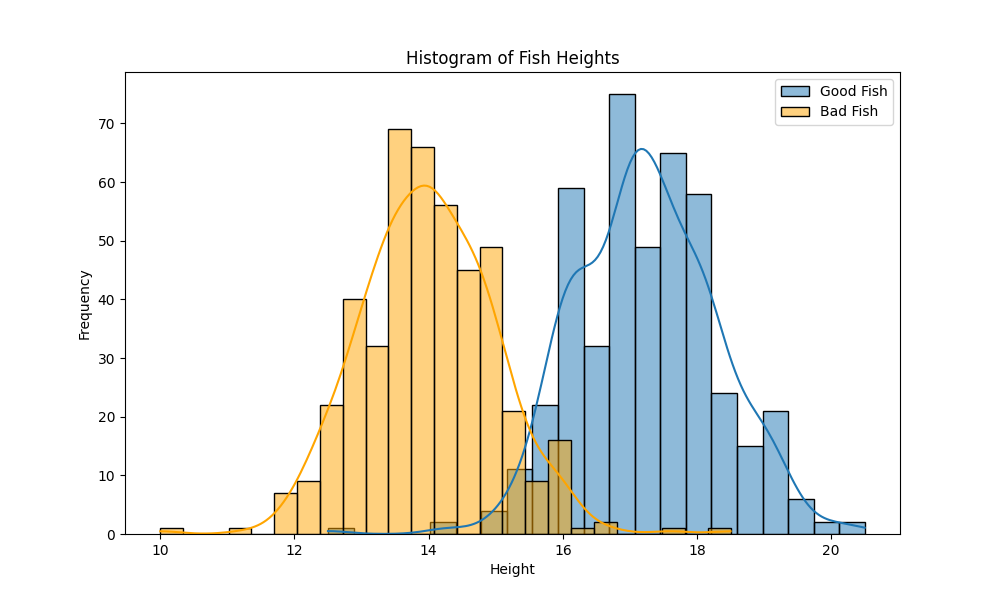

In [ ]:
# prompt: give me code to plot good_df and bad_df heights' histograms in the same figure using matplotlib and seaborn but the no. of rows of both dataframes should be the min(good_df.shape[0], bad_df.shape[0])

# Determine the minimum number of rows between the two dataframes
min_rows = min(good_df.shape[0], bad_df.shape[0])

# Sample the dataframes to have the same number of rows
good_df_sample = good_df.sample(n=min_rows, random_state=42)
bad_df_sample = bad_df.sample(n=min_rows, random_state=42)

# Create a figure and axes
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the histograms for good_df and bad_df
sns.histplot(good_df_sample['height'], ax=ax, label='Good Fish', kde=True)
sns.histplot(bad_df_sample['height'], ax=ax, label='Bad Fish', kde=True, color='orange')

# Add a legend and labels
ax.legend()
ax.set_xlabel('Height')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Fish Heights')

plt.show()

In [ ]:
bad_df['date'].nunique()

21

In [ ]:
bad_df['date'].unique()

array(['2024-01-30', '2024-01-31', '2024-02-20', '2024-02-22',
       '2024-02-28', '2024-02-29', '2024-03-12', '2024-03-13',
       '2024-03-19', '2024-03-20', '2024-03-23', '2024-03-26',
       '2024-03-27', '2024-03-28', '2024-03-30', '2024-04-05',
       '2024-04-17', '2024-05-02', '2024-05-14', '2024-05-16',
       '2024-05-25'], dtype=object)

In [ ]:
good_df['date'].nunique()

7

In [ ]:
good_df['date'].unique()

array(['2024-02-13', '2024-02-15', '2024-02-22', '2024-02-24',
       '2024-02-29', '2024-03-02', '2024-03-13'], dtype=object)

In [ ]:
set(good_df['date'].unique()).intersection(set(bad_df['date'].unique()))

{'2024-02-22', '2024-02-29', '2024-03-13'}

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

def plot_height_histogram(date, bad_df_samples, good_df_samples):
    """
    Plots the height histograms for both bad and good dataframes on the given date.

    Args:
      date: The date to filter the data by.
      bad_df_samples: DataFrame for 'bad' samples.
      good_df_samples: DataFrame for 'good' samples.
    """
    # Filter both dataframes by the selected date
    bad_filtered_df = bad_df_samples[bad_df_samples['date'] == date]
    good_filtered_df = good_df_samples[good_df_samples['date'] == date]

    # Create a figure and axes
    plt.close('all')
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the histograms for good_df and bad_df
    sns.histplot(good_filtered_df['height'], ax=ax, label='Good Fish', kde=True)
    sns.histplot(bad_filtered_df['height'], ax=ax, label='Bad Fish', kde=True, color='orange')

    # Add a legend and labels
    ax.legend()
    ax.set_xlabel('Height')
    ax.set_ylabel('Frequency')
    ax.set_title('Histogram of Fish Heights')

    plt.show()


min_rows = min(good_df.shape[0], bad_df.shape[0])

# Sample the dataframes to have the same number of rows
good_df_samples = good_df.sample(n=min_rows, random_state=42)
bad_df_samples = bad_df.sample(n=min_rows, random_state=42)

# Create a dropdown widget for selecting the date
date_dropdown = widgets.Dropdown(
    options=bad_df_samples['date'].unique(),
    value=bad_df_samples['date'].unique()[0],
    description='Select Date:',
)

# Create an interactive output widget
out = widgets.Output()

# Define the interactive function
def on_date_change(change):
    with out:
        out.clear_output()
        plot_height_histogram(change.new, bad_df_samples, good_df_samples)

# Observe the dropdown widget for changes
date_dropdown.observe(on_date_change, names='value')

# Display the widgets
display(date_dropdown, out)


Dropdown(description='Select Date:', options=('2024-03-26', '2024-03-27', '2024-03-13', '2024-02-28', '2024-01…

Output()